In [1]:
import jax
# jax.config.update('jax_platform_name', 'cpu')

import jax.numpy as jnp
from jax import config, jit, random, grad, vmap, flatten_util, hessian

from jax import random

import scipy.integrate as integrate

from thermo_oscillator_network_fns import energy_network, setup_integration, integrate_dofs

from scipy.stats import multivariate_normal

import os

import matplotlib.pyplot as plt

CUDA backend failed to initialize: Unable to use CUDA because of the following issues with CUDA components:
Outdated cuDNN installation found.
Version JAX was built against: 8907
Minimum supported: 9100
Installed version: 8907
The local installation version must be no lower than 9100..(Set TF_CPP_MIN_LOG_LEVEL=0 and rerun for more info.)


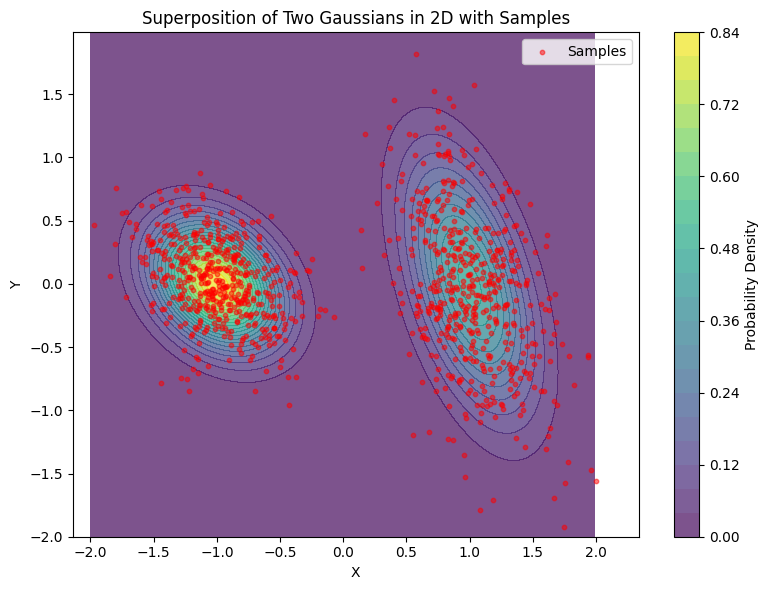

In [2]:
def sample_from_superposition(mu1, sigma1, mu2, sigma2, p1, n_samples, key):
    """
    Samples from a superposition of two Gaussian distributions in 2D using JAX.
    """
    key1, key2, key3 = random.split(key, 3)
    
    # Sample from both Gaussians
    samples1 = random.multivariate_normal(key1, mu1, sigma1, shape=(n_samples,))
    samples2 = random.multivariate_normal(key2, mu2, sigma2, shape=(n_samples,))
    
    # Generate random numbers to decide which sample to keep
    choices = random.uniform(key3, shape=(n_samples,)) < p1
    
    # Select samples based on the choices
    samples = jnp.where(choices[:, None], samples1, samples2)
    
    return samples

def gaussian_pdf(x, y, mu, sigma):
    """Compute the PDF of a 2D Gaussian distribution."""
    pos = jnp.dstack((x, y))
    return multivariate_normal.pdf(pos, mean=mu, cov=sigma)

# Parameters for the first Gaussian
mu1 = jnp.array([1, 0])
sigma1 = jnp.array([[0.1, -0.1], [-0.1, 0.4]])

# Parameters for the second Gaussian
mu2 = jnp.array([-1, 0])
sigma2 = jnp.array([[0.1, -0.03], [-.03, 0.1]])

# Probability of sampling from the first Gaussian
p1 = 0.5

# Number of samples to generate
n_samples = 1000

# JAX random key
key = random.PRNGKey(0)

# Generate samples
samples = sample_from_superposition(mu1, sigma1, mu2, sigma2, p1, n_samples, key)

# Create a grid for the contour plot
x_lim = 2
y_lim = 2
x, y = jnp.mgrid[-x_lim:x_lim:.01, -y_lim:y_lim:.01]

# Compute the PDF for both Gaussians
z1 = gaussian_pdf(x, y, mu1, sigma1)
z2 = gaussian_pdf(x, y, mu2, sigma2)

# Combine the PDFs according to the mixture weights
z = p1 * z1 + (1 - p1) * z2

# Create the plot
plt.figure(figsize=(8, 6))

# Plot the contour of the combined distribution
plt.contourf(x, y, z, levels=20, cmap='viridis', alpha=0.7)
plt.colorbar(label='Probability Density')

# Plot the samples
plt.scatter(samples[:, 0], samples[:, 1], color='red', alpha=0.5, s=10, label='Samples')

plt.title('Superposition of Two Gaussians in 2D with Samples')
plt.xlabel('X')
plt.ylabel('Y')
plt.legend()
plt.axis('equal')
plt.tight_layout()
plt.show()

In [3]:
# # Duffing params
k_lin= jnp.array([25.582, 0.394784])
k_duff = jnp.array([1., 1.0])
c_lin = jnp.array([.0])
c_optomech = jnp.array([0. ]) #12.
connectivity = jnp.array([[0, 1]])

marginalized_dofs = None #jnp.array([0,3])
non_marginalized_dofs = jnp.array([0,1])

In [4]:
integration_limits = (-0.063, 0.063)
if marginalized_dofs is not None:
    get_integrands = setup_integration(marginalized_dofs, integration_limits=integration_limits, num_integration_points=10)
else:
    get_integrands = setup_integration(non_marginalized_dofs, integration_limits=(-2, 2), num_integration_points=10)

In [5]:
if marginalized_dofs is not None:
    energy_network_marg = integrate_dofs(get_integrands, energy_network, marginalized_dofs, non_marginalized_dofs)
else:
    energy_network_marg = energy_network

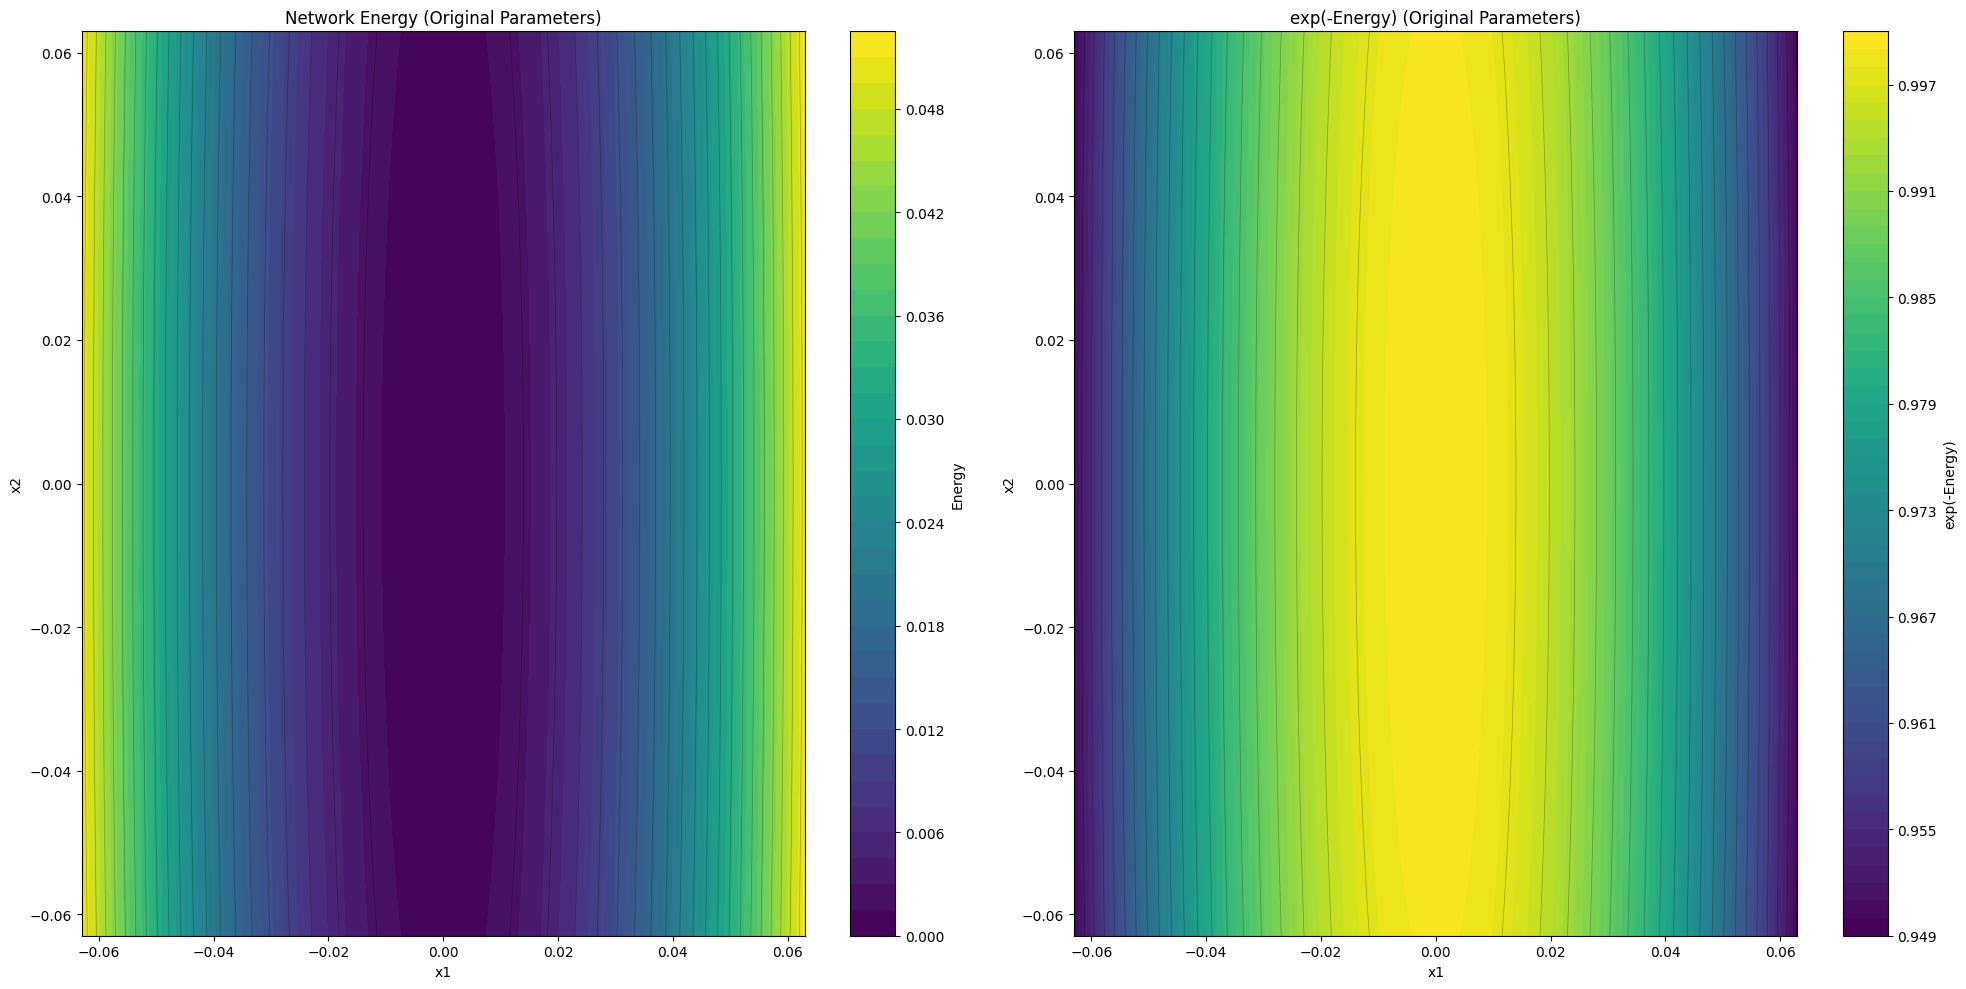

Original parameters: k_lin=[25.582     0.394784], k_duff=[1. 1.], c_lin=[0.], c_optomech=[0.]
Integration limits: (-0.063, 0.063)


In [6]:
# Define the grid for plotting using integration limits
x1_values = jnp.linspace(integration_limits[0], integration_limits[1], 100)
x2_values = jnp.linspace(integration_limits[0], integration_limits[1], 100)
X1, X2 = jnp.meshgrid(x1_values, x2_values)

# Calculate energy values for original parameters
energy_values_original = vmap(lambda x1, x2: energy_network_marg(jnp.array([x1, x2]), k_lin, k_duff, c_lin, c_optomech, connectivity))(X1.ravel(), X2.ravel())
energy_values_original = energy_values_original.reshape(X1.shape)

# Calculate exp(-energy) values
exp_neg_energy = jnp.exp(-energy_values_original)

# Create the plot with two subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 10))

# Plot original energy
contour1 = ax1.contourf(X1, X2, energy_values_original, levels=50, cmap='viridis')
ax1.set_title("Network Energy (Original Parameters)")
ax1.set_xlabel("x1")
ax1.set_ylabel("x2")
cbar1 = fig.colorbar(contour1, ax=ax1, label='Energy')

# Add contour lines for better visibility of energy levels
ax1.contour(X1, X2, energy_values_original, levels=20, colors='k', alpha=0.3, linewidths=0.5)

# Plot exp(-energy)
contour2 = ax2.contourf(X1, X2, exp_neg_energy, levels=50, cmap='viridis')
ax2.set_title("exp(-Energy) (Original Parameters)")
ax2.set_xlabel("x1")
ax2.set_ylabel("x2")
cbar2 = fig.colorbar(contour2, ax=ax2, label='exp(-Energy)')

# Add contour lines for better visibility of exp(-energy) levels
ax2.contour(X1, X2, exp_neg_energy, levels=20, colors='k', alpha=0.3, linewidths=0.5)

plt.tight_layout()
plt.show()

# Print original parameter values for reference
print(f"Original parameters: k_lin={k_lin}, k_duff={k_duff}, c_lin={c_lin}, c_optomech={c_optomech}")
print(f"Integration limits: {integration_limits}")

In [7]:

def loss_fn(k_lin, k_duff, c_lin, c_optomech):
    # Redefine network_deformation_energy with current k1 and k2
    def current_network_energy(x):
        return energy_network_marg(x, k_lin, k_duff, c_lin, c_optomech, connectivity)
    
    # Recompute score and score2 with current energy function
    current_score = grad(current_network_energy)
    current_score2 = hessian(current_network_energy)
    
    # Recompute score_loss_per_sample with current score and score2
    current_score_loss_per_sample = lambda x: (-jnp.trace(current_score2(x)) + 1/2 * jnp.sum(current_score(x)**2))/n_samples   
    # Compute total loss
    return jnp.sum(vmap(current_score_loss_per_sample)(samples))

# Compute gradients of the loss with respect to k1 and k2
@jit
def grad_loss(k_lin, k_duff, c_lin, c_optomech):
    return grad(loss_fn, argnums=(0, 1, 2, 3))(k_lin, k_duff, c_lin, c_optomech)

# Compute Hessian of the loss function
@jit
def hessian_loss(k_lin, k_duff, c_lin, c_optomech):
    return hessian(loss_fn, argnums=(0, 1, 2, 3))(k_lin, k_duff, c_lin, c_optomech)



In [8]:
# num_iterations = 10001
num_iterations = 101
# Initial values
k_lin_opt = k_lin
k_duff_opt = k_duff
c_lin_opt = c_lin
c_optomech_opt = c_optomech

design_mask = jnp.array([1, 0, 0, 1])

# List to store loss values
loss_values = []

# Optimization loop
for i in range(num_iterations + 1):
    # Compute gradients and Hessian
    grads = grad_loss(k_lin_opt, k_duff_opt, c_lin_opt, c_optomech_opt)
    hess = hessian_loss(k_lin_opt, k_duff_opt, c_lin_opt, c_optomech_opt)
    
    # Combine parameters and apply design mask
    params = jnp.concatenate([k_lin_opt, k_duff_opt, c_lin_opt, c_optomech_opt])
    masked_grads = jnp.concatenate([g * m for g, m in zip(grads, design_mask)])
    masked_hess = jnp.block([[h * m1 * m2 for h, m2 in zip(row, design_mask)] for row, m1 in zip(hess, design_mask)])
    
    # Compute update direction (solving Hx = -g)
    update = jnp.linalg.solve(masked_hess + 1e-4 * jnp.eye(masked_hess.shape[0]), -masked_grads)
    
    # Apply update
    params = params + update
    
    # Extract updated parameters
    k_lin_opt, k_duff_opt, c_lin_opt, c_optomech_opt = jnp.split(params, [2, 4, 5])
    
    # Save and print progress every 10 iterations
    if i % 10 == 0 or i == num_iterations:
        current_loss = loss_fn(k_lin_opt, k_duff_opt, c_lin_opt, c_optomech_opt)
        loss_values.append(jnp.float32(current_loss))
        print(f"Iteration {i}, Loss: {current_loss}, k_lin: {k_lin_opt}, k_duff: {k_duff_opt}, c_lin: {c_lin_opt}, c_optomech: {c_optomech_opt}")

Iteration 0, Loss: -3.854332685470581, k_lin: [-0.61271286  3.5378044 ], k_duff: [1. 1.], c_lin: [0.], c_optomech: [-0.33469486]
Iteration 10, Loss: -3.8543357849121094, k_lin: [-0.61506474  3.5392358 ], k_duff: [1. 1.], c_lin: [0.], c_optomech: [-0.33481163]
Iteration 20, Loss: -3.8543357849121094, k_lin: [-0.61506474  3.5392358 ], k_duff: [1. 1.], c_lin: [0.], c_optomech: [-0.33481163]
Iteration 30, Loss: -3.8543357849121094, k_lin: [-0.61506474  3.5392358 ], k_duff: [1. 1.], c_lin: [0.], c_optomech: [-0.33481163]
Iteration 40, Loss: -3.8543357849121094, k_lin: [-0.61506474  3.5392358 ], k_duff: [1. 1.], c_lin: [0.], c_optomech: [-0.33481163]
Iteration 50, Loss: -3.8543357849121094, k_lin: [-0.61506474  3.5392358 ], k_duff: [1. 1.], c_lin: [0.], c_optomech: [-0.33481163]
Iteration 60, Loss: -3.8543357849121094, k_lin: [-0.61506474  3.5392358 ], k_duff: [1. 1.], c_lin: [0.], c_optomech: [-0.33481163]
Iteration 70, Loss: -3.8543357849121094, k_lin: [-0.61506474  3.5392358 ], k_duff: [1

In [9]:
# # Optimization parameters
# learning_rate = 0.01
# num_iterations = 10001

# # Initial values for k1 and k2
# k_lin_opt = k_lin
# k_duff_opt = k_duff
# c_lin_opt = c_lin
# c_optomech_opt = c_optomech

# design_mask = jnp.array([1, 0, 0, 1])

# # List to store loss values
# loss_values = []

# # Optimization loop
# for i in range(num_iterations+1):
#     # Compute gradients
#     grads = grad_loss(k_lin_opt, k_duff_opt, c_lin_opt, c_optomech_opt)
    
#     # Update k1 and k2
#     k_lin_opt = k_lin_opt - learning_rate * grads[0]*design_mask[0]
#     k_duff_opt = k_duff_opt - learning_rate * grads[1]*design_mask[1]
#     c_lin_opt = c_lin_opt - learning_rate * grads[2]*design_mask[2]
#     c_optomech_opt = c_optomech_opt - learning_rate * grads[3]*design_mask[3]
    
#     # Save and print progress every 100 iterations
#     if i % 10 == 0 or i == num_iterations:
#         current_loss = loss_fn(k_lin_opt, k_duff_opt, c_lin_opt, c_optomech_opt)
#         loss_values.append(jnp.float32(current_loss))
#         print(f"Iteration {i}, Loss: {current_loss}, k_lin: {k_lin_opt}, k_duff: {k_duff_opt}, c_lin: {c_lin_opt}, c_optomech: {c_optomech_opt}")

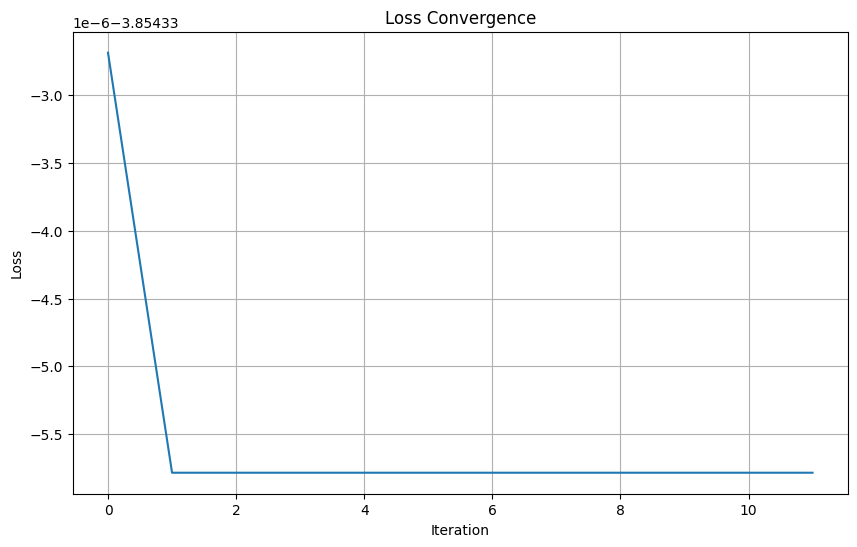

In [10]:
plt.figure(figsize=(10, 6))
plt.plot( loss_values)
plt.title('Loss Convergence')
plt.xlabel('Iteration')
plt.ylabel('Loss')
# plt.yscale('log')  # Use log scale for y-axis to better visualize the convergence
plt.grid(True)
# Show the plot (optional, you can comment this out if you don't need to display it)
plt.show()

# # Create a descriptive filename
# folder_filename = f"2d_mu1_{mu1[0]:.1f}_{mu1[1]:.1f}_mu2_{mu2[0]:.1f}_{mu2[1]:.1f}"

# convergence_filename = f"free_dofs_{len(non_marginalized_dofs)}_marginalized_dofs_{len(marginalized_dofs)}_"
# convergence_filename += f"k_lin_opt_{'yes' if design_mask[0]==1 else 'no'}_"
# convergence_filename += f"k_duff_opt_{'yes' if design_mask[1]==1 else 'no'}_"
# convergence_filename += f"c_lin_opt_{'yes' if design_mask[2]==1 else 'no'}_"
# convergence_filename += f"c_optomech_opt_{'yes' if design_mask[3]==1 else 'no'}_"
# convergence_filename += f"numSamples_{n_samples}_numIterations_{num_iterations}_finalLoss_{loss_values[-1]:.2f}_convergence.png"


# # Create the folder if it doesn't exist
# folder_path = f'results/{folder_filename}'
# os.makedirs(folder_path, exist_ok=True)

# # Save the figure
# plt.savefig(f'{folder_path}/{convergence_filename}', dpi=300, bbox_inches='tight')





In [11]:
# Plot Network Deformation Energy for original and optimized k values, and distribution with samples
x1_values = jnp.linspace(-x_lim, x_lim, 20)
x2_values = jnp.linspace(-y_lim, y_lim, 20)
X1, X2 = jnp.meshgrid(x1_values, x2_values)

# Calculate energy values for original k
energy_values_original = vmap(lambda x1, x2: energy_network_marg(jnp.array([x1, x2]).T, k_lin, k_duff, c_lin, c_optomech, connectivity))(X1.ravel(), X2.ravel())
energy_values_original = energy_values_original.reshape(X1.shape)

# Calculate energy values for optimized k
energy_values_optimized = vmap(lambda x1, x2: energy_network_marg(jnp.array([x1, x2]).T, k_lin_opt, k_duff_opt, c_lin_opt, c_optomech_opt, connectivity))(X1.ravel(), X2.ravel())
energy_values_optimized = energy_values_optimized.reshape(X1.shape)

# Calculate probability values for the entire grid
prob_from_energy_opt = lambda x1, x2: jnp.exp(-energy_network_marg(jnp.array([x1, x2]).T, k_lin_opt, k_duff_opt, c_lin_opt, c_optomech_opt, connectivity))
prob_from_energy_vals = vmap(vmap(prob_from_energy_opt))(X1, X2)


# Normalize the probability values using the custom integrator
def compute_integrand(x):
    return jnp.exp(-energy_network_marg(x, k_lin_opt, k_duff_opt, c_lin_opt, c_optomech_opt, connectivity))

# Use the custom integrator
norm_const_opt = jnp.sum(get_integrands(compute_integrand))

prob_from_energy_normalized = prob_from_energy_vals / norm_const_opt


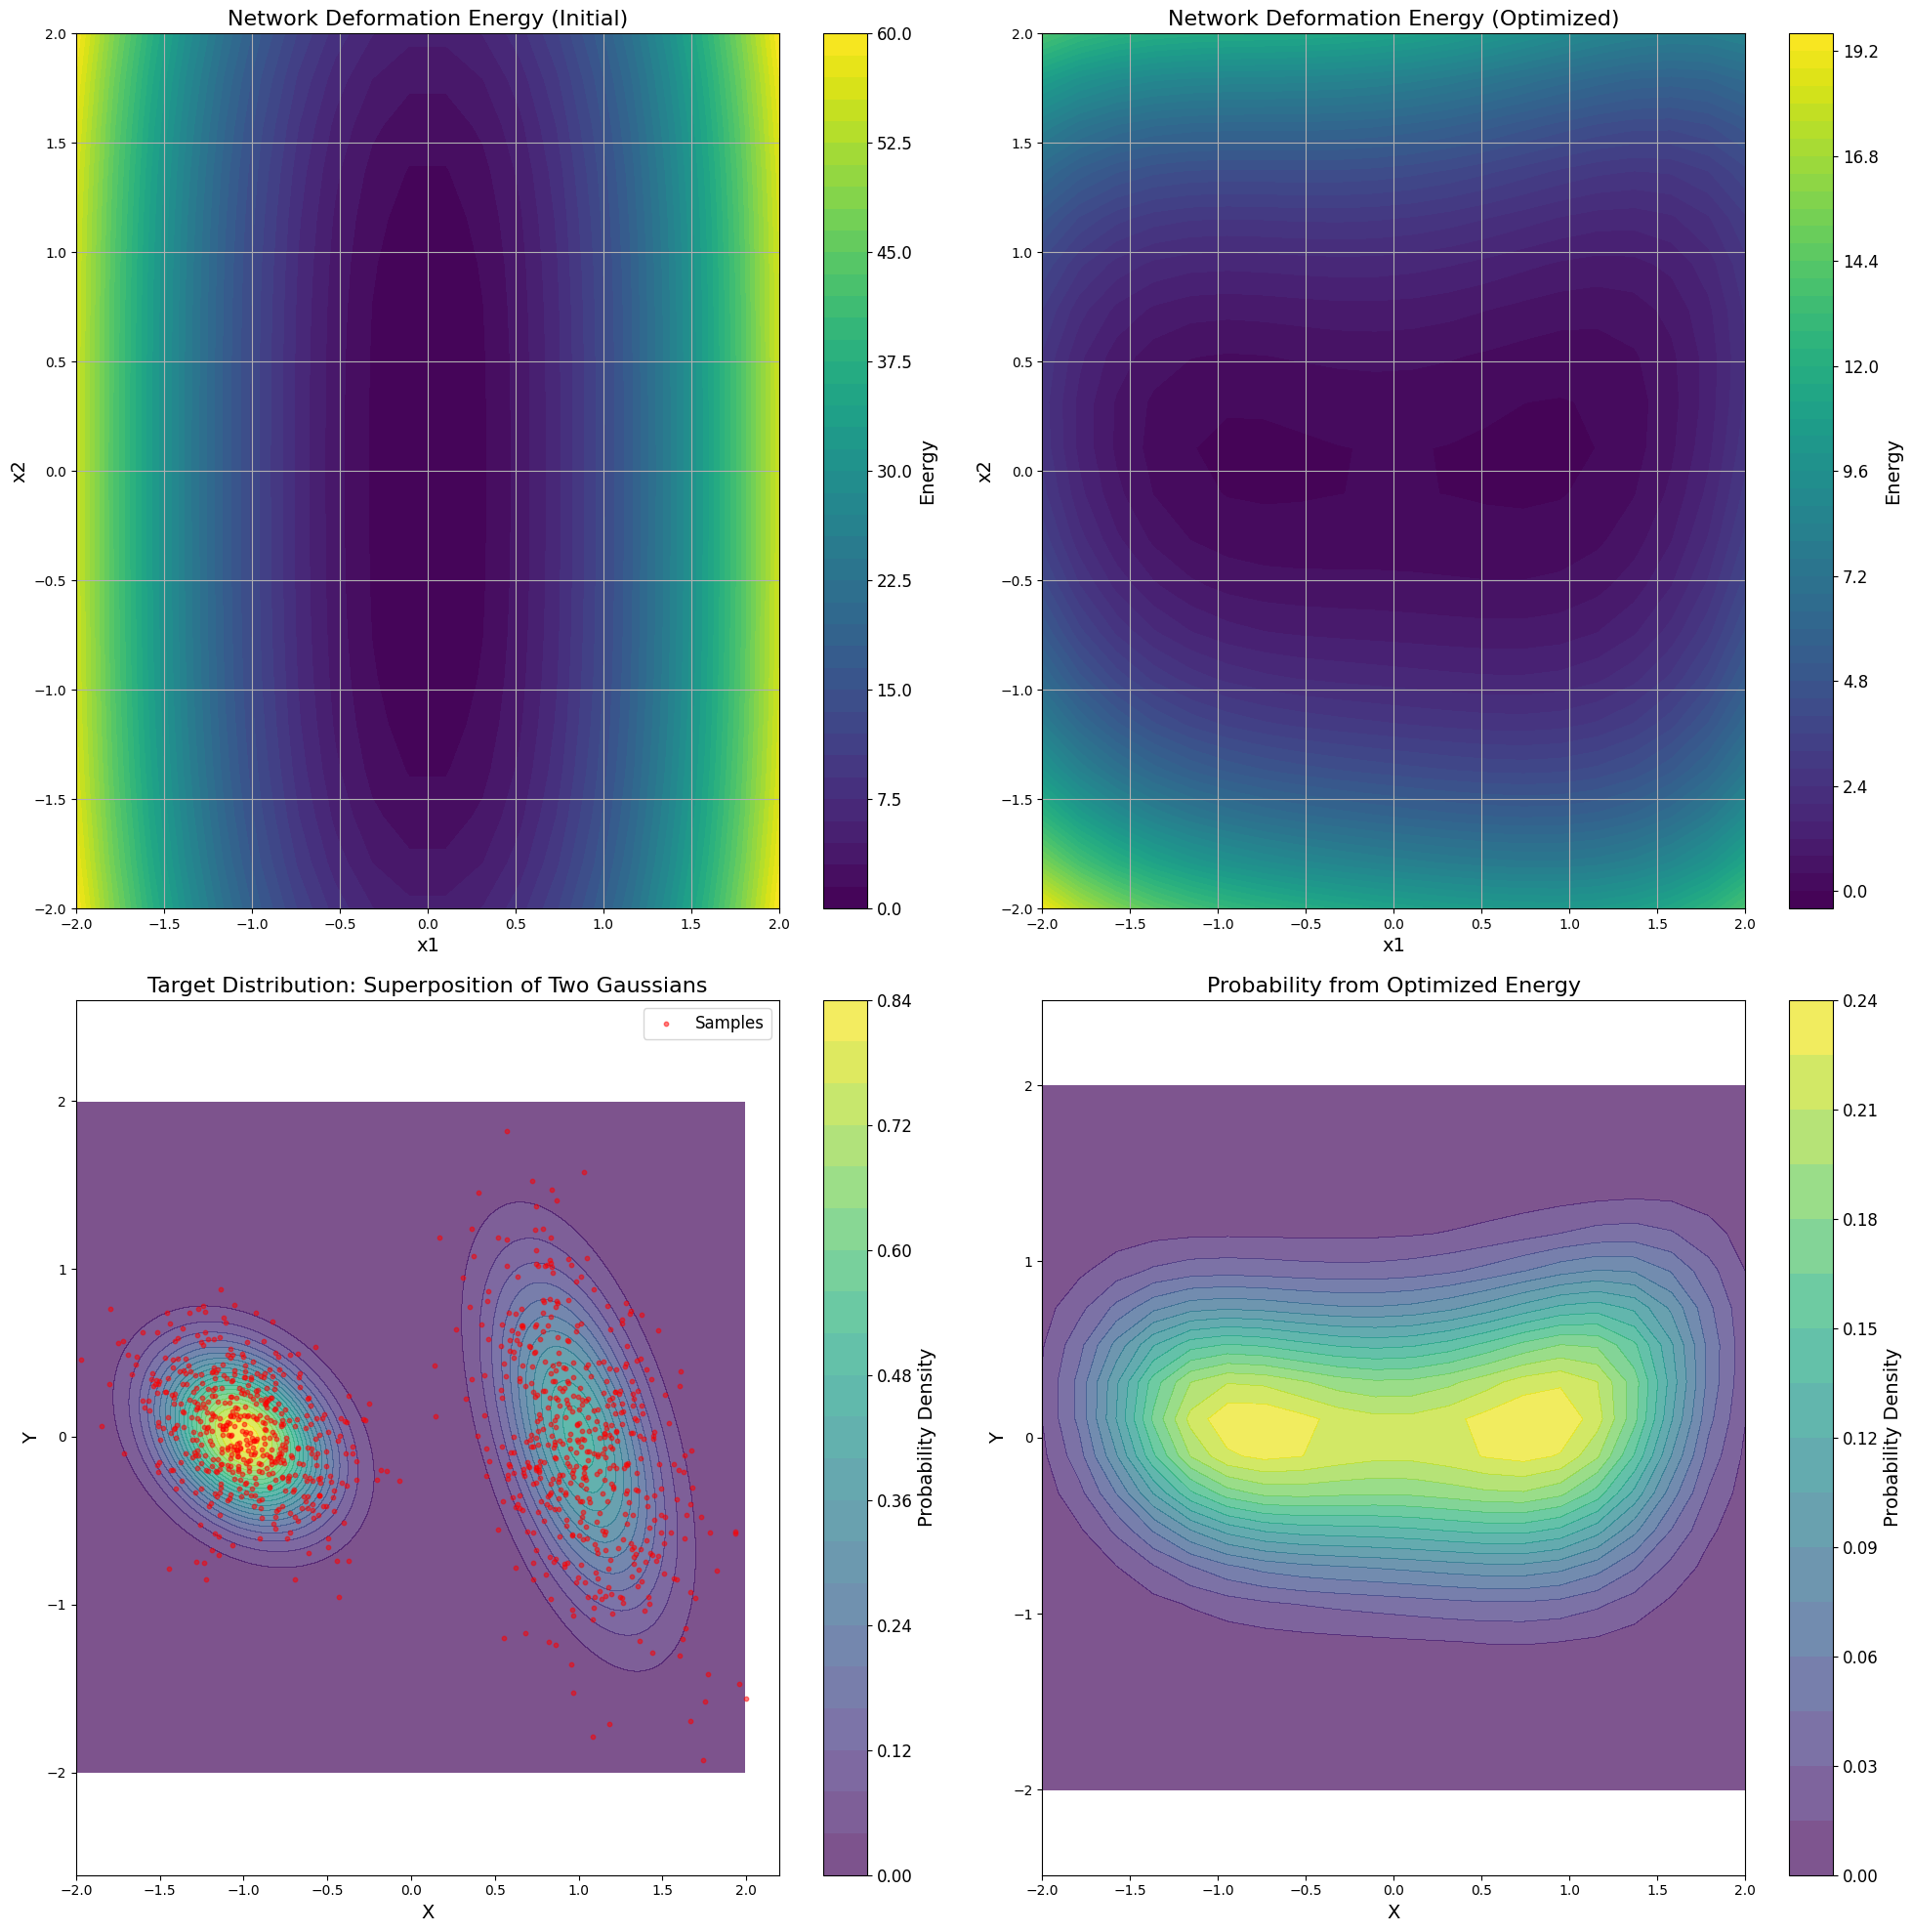

Original k_lin: [25.582     0.394784], k_duff: [1. 1.], c_lin: [0.], c_optomech: [0.]
Optimized k_lin: [-0.6150646  3.539235 ], k_duff: [1. 1.], c_lin: [0.], c_optomech: [-0.3348115]


In [12]:
# ... (previous code remains the same)

# Create 2x2 subplots
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(20, 20))

# Increase font size for all text elements
plt.rcParams.update({'font.size': 14})

# Plot original k energy
contour1 = ax1.contourf(X1, X2, energy_values_original, levels=50, cmap='viridis')
cbar1 = fig.colorbar(contour1, ax=ax1)
cbar1.set_label('Energy', fontsize=14)
ax1.set_title("Network Deformation Energy (Initial)", fontsize=16)
ax1.set_xlabel("x1", fontsize=14)
ax1.set_ylabel("x2", fontsize=14)
ax1.grid(True)

# Plot optimized k energy
contour2 = ax2.contourf(X1, X2, energy_values_optimized, levels=50, cmap='viridis')
cbar2 = fig.colorbar(contour2, ax=ax2)
cbar2.set_label('Energy', fontsize=14)
ax2.set_title("Network Deformation Energy (Optimized)", fontsize=16)
ax2.set_xlabel("x1", fontsize=14)
ax2.set_ylabel("x2", fontsize=14)
ax2.grid(True)

# Plot target distribution
x, y = jnp.mgrid[-x_lim:x_lim:.01, -y_lim:y_lim:.01]
z1 = gaussian_pdf(x, y, mu1, sigma1)
z2 = gaussian_pdf(x, y, mu2, sigma2)
z = p1 * z1 + (1 - p1) * z2

contour3 = ax3.contourf(x, y, z, levels=20, cmap='viridis', alpha=0.7)
cbar3 = fig.colorbar(contour3, ax=ax3)
cbar3.set_label('Probability Density', fontsize=14)
ax3.scatter(samples[:, 0], samples[:, 1], color='red', alpha=0.5, s=10, label='Samples')
ax3.set_title('Target Distribution: Superposition of Two Gaussians', fontsize=16)
ax3.set_xlabel('X', fontsize=14)
ax3.set_ylabel('Y', fontsize=14)
ax3.legend(fontsize=12)
ax3.axis('equal')

# Plot probability from optimized energy
contour4 = ax4.contourf(X1, X2, prob_from_energy_normalized, levels=20, cmap='viridis', alpha=0.7)
cbar4 = fig.colorbar(contour4, ax=ax4)
cbar4.set_label('Probability Density', fontsize=14)
ax4.set_title('Probability from Optimized Energy', fontsize=16)
ax4.set_xlabel('X', fontsize=14)
ax4.set_ylabel('Y', fontsize=14)
ax4.axis('equal')

# Increase font size for colorbar labels
for cbar in [cbar1, cbar2, cbar3, cbar4]:
    cbar.ax.tick_params(labelsize=12)

plt.tight_layout()

# filename = convergence_filename.replace("_convergence.png", ".png")

# # Save the figure to the results folder
# plt.savefig(f'results/{folder_filename}/{filename}', dpi=300, bbox_inches='tight')

plt.show()

# Print k values for reference
print(f"Original k_lin: {k_lin}, k_duff: {k_duff}, c_lin: {c_lin}, c_optomech: {c_optomech}")
print(f"Optimized k_lin: {k_lin_opt}, k_duff: {k_duff_opt}, c_lin: {c_lin_opt}, c_optomech: {c_optomech_opt}")